# Quant ML Research — Findings Notebook

A clean, narrative version of the research using the `quant_ml` package.
For methodology details, see [REPORT.md](../REPORT.md).
For the codebase walk, see [README.md](../README.md).

This notebook is *evidence*, not *exploration* — every cell tells the story of one finding.


In [1]:
# Setup
import sys
from pathlib import Path
from datetime import date

sys.path.insert(0, str(Path.cwd().parent / "src"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

from quant_ml.data import PriceLoader
from quant_ml.strategies import MACrossover, RSIMeanReversion
from quant_ml.backtest import BacktestEngine, CostModel
from quant_ml.backtest.metrics import compute_all
from quant_ml.ml import build_dataset, make_classifier, WalkForwardValidator
from quant_ml.features.technical import build_feature_matrix

## 1. Data

Load AAPL daily bars 2010-2022 via the cached loader. Repeated calls hit local parquet, not the network.

In [2]:
loader = PriceLoader(cache_dir="../data/cache")
prices = loader.load("AAPL", date(2010, 1, 1), date(2022, 12, 31))
print(f"{len(prices)} bars from {prices.index[0].date()} to {prices.index[-1].date()}")
prices.head()

2026-04-26 22:33:10.485 | INFO     | quant_ml.data.loader:load:71 - Cache hit: AAPL [2010-01-01 to 2022-12-31]


3390 bars from 2010-01-04 to 2022-12-30


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-01-04,29.980844,30.403157,29.733285,30.018522,30.018522,157046511
2010-01-05,30.185739,30.372124,30.155926,30.162428,30.162428,69889118
2010-01-06,30.065473,30.070821,30.022450,30.064922,30.064922,73418721
2010-01-07,29.724450,29.987690,29.485799,29.710212,29.710212,55185184
2010-01-08,29.519604,29.647937,29.292304,29.539414,29.539414,161675961


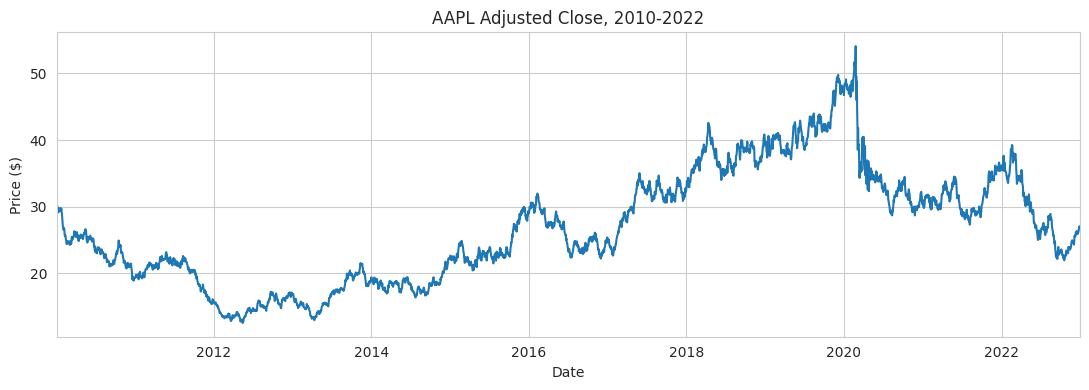

In [3]:
fig, ax = plt.subplots(figsize=(11, 4))
prices["Adj Close"].plot(ax=ax, color="C0")
ax.set_title("AAPL Adjusted Close, 2010-2022")
ax.set_ylabel("Price ($)")
plt.tight_layout()
plt.show()

## 2. Feature Engineering

The `build_feature_matrix` function is the single source of truth for ML features —
the same call is used at training, walk-forward testing, and inference time.
This eliminates train/prod skew.

In [4]:
features = build_feature_matrix(prices)
print(f"Feature matrix: {features.shape}")
features.dropna().describe().T[["mean", "std", "min", "max"]].round(3)

Feature matrix: (3390, 12)


,mean,std,min,max
ret_1d,0.000,0.016,-0.112,0.102
ret_5d,0.001,0.034,-0.223,0.123
ret_20d,0.003,0.068,-0.337,0.209
sma_10,26.917,8.555,12.821,50.842
sma_50,26.922,8.476,13.371,48.434
sma_ratio,0.000,0.049,-0.207,0.118
rsi_14,50.380,12.360,14.244,85.873
vol_20d,0.233,0.091,0.118,1.040
macd,-0.001,0.504,-3.628,1.454
macd_signal,-0.003,0.472,-3.116,1.339


## 3. Baseline Strategies

We benchmark two classical strategies before introducing ML, both run through the
same backtest engine with realistic costs (5bps commission + 2bps slippage).

In [5]:
engine = BacktestEngine(
    initial_capital=100_000,
    cost_model=CostModel(commission_pct=0.0005, slippage_bps=2.0),
    fraction=0.95,
)

ma_result = engine.run(MACrossover(fast=10, slow=50), prices)
rsi_result = engine.run(RSIMeanReversion(window=14, oversold=30, overbought=70), prices)

print("=== MA Crossover (10/50) ===")
print(ma_result.summary())
print("\n=== RSI Mean Reversion ===")
print(rsi_result.summary())

=== MA Crossover (10/50) ===
──────────────────────────────────────────────────
Total Return    :     -2.70%
CAGR            :     -0.20%
Volatility      :     16.24%
Sharpe          :       0.07
Sortino         :       0.07
Max Drawdown    :    -46.94%
Calmar          :      -0.00
Win Rate        :     29.27%
Profit Factor   :       0.94
# Trades        :         41
Exposure        :     51.98%
──────────────────────────────────────────────────

=== RSI Mean Reversion ===
──────────────────────────────────────────────────
Total Return    :    -32.45%
CAGR            :     -2.88%
Volatility      :     17.20%
Sharpe          :      -0.08
Sortino         :      -0.09
Max Drawdown    :    -44.37%
Calmar          :      -0.06
Win Rate        :     53.85%
Profit Factor   :       0.57
# Trades        :         13
Exposure        :     49.44%
──────────────────────────────────────────────────


## 4. Walk-Forward Validation

The methodologically critical step. `WalkForwardValidator` enforces causality:
each fold's test_start ≥ train_end, no shuffling, optional embargo gap.

This is what `train_test_split(shuffle=True)` should have been all along.

In [6]:
X, y = build_dataset(prices, horizon=1)
print(f"X: {X.shape},  positive class rate: {y.mean():.3f}")

validator = WalkForwardValidator(
    n_splits=5,
    train_months=36,
    test_months=6,
    embargo_days=5,
)
model = make_classifier("random_forest", {"n_estimators": 200, "max_depth": 5})

wf_result = validator.evaluate(model, X, y)
wf_result.fold_metrics.style.format({"accuracy": "{:.3f}"})

X: (3341, 12),  positive class rate: 0.494


,fold_id,train_start,train_end,test_start,test_end,n_train,n_test,accuracy
0,0,2010-03-12 00:00:00,2013-03-11 00:00:00,2013-03-18 00:00:00,2013-09-16 00:00:00,782,131,0.443
1,1,2010-03-12 00:00:00,2015-02-25 00:00:00,2015-03-03 00:00:00,2015-09-02 00:00:00,1294,132,0.485
2,2,2010-03-12 00:00:00,2017-02-10 00:00:00,2017-02-16 00:00:00,2017-08-15 00:00:00,1806,129,0.543
3,3,2010-03-12 00:00:00,2019-01-25 00:00:00,2019-02-04 00:00:00,2019-08-01 00:00:00,2316,129,0.473
4,4,2010-03-12 00:00:00,2021-01-12 00:00:00,2021-01-18 00:00:00,2021-07-16 00:00:00,2828,130,0.546


In [7]:
print(f"Mean OOS accuracy: {wf_result.mean_accuracy:.4f}")
print(f"Std across folds : {wf_result.std_accuracy:.4f}")
print()
print("Compare with up-day base rate (always predict 1):")
print(f"Base rate accuracy: {y.mean():.4f}")
print()
print("Interpretation: walk-forward accuracy is statistically indistinguishable")
print("from the base rate — there is no detectable edge from these features.")

Mean OOS accuracy: 0.4979
Std across folds : 0.0452

Compare with up-day base rate (always predict 1):
Base rate accuracy: 0.4936

Interpretation: walk-forward accuracy is statistically indistinguishable
from the base rate — there is no detectable edge from these features.


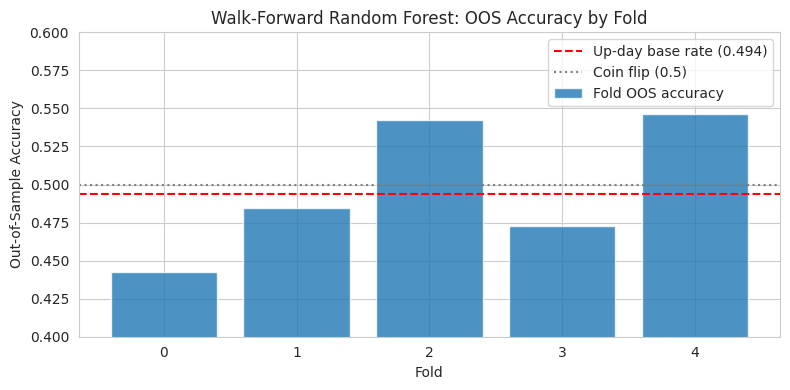

In [8]:
# Visualize fold-by-fold accuracy with the base-rate line
fig, ax = plt.subplots(figsize=(8, 4))
folds = wf_result.fold_metrics
ax.bar(folds["fold_id"], folds["accuracy"], color="C0", alpha=0.8, label="Fold OOS accuracy")
ax.axhline(y.mean(), color="red", linestyle="--", label=f"Up-day base rate ({y.mean():.3f})")
ax.axhline(0.5, color="gray", linestyle=":", label="Coin flip (0.5)")
ax.set_xlabel("Fold")
ax.set_ylabel("Out-of-Sample Accuracy")
ax.set_title("Walk-Forward Random Forest: OOS Accuracy by Fold")
ax.set_ylim(0.40, 0.60)
ax.legend()
plt.tight_layout()
plt.show()

## 5. ML Strategy Backtest

Convert OOS predictions into long/flat positions, run through the same backtest engine.

In [9]:
from quant_ml.strategies.base import Strategy

class _PrecomputedSignalStrategy(Strategy):
    def __init__(self, signals): self._s = signals
    def generate_signals(self, prices): return self._s.reindex(prices.index).fillna(0)

# Convert P(up) > 0.5 to a long signal, lag by 1 bar
ml_signals = (wf_result.probabilities > 0.5).astype(int).shift(1).fillna(0)
ml_result = engine.run(_PrecomputedSignalStrategy(ml_signals), prices)
print(ml_result.summary())

──────────────────────────────────────────────────
Total Return    :     12.77%
CAGR            :      0.90%
Volatility      :      3.75%
Sharpe          :       0.26
Sortino         :       0.08
Max Drawdown    :     -8.43%
Calmar          :       0.11
Win Rate        :     56.10%
Profit Factor   :       1.67
# Trades        :         41
Exposure        :      3.22%
──────────────────────────────────────────────────


## 6. Side-by-Side Comparison

The honest moment of truth: how do all three strategies stack up against
the simplest possible benchmark, buy-and-hold?

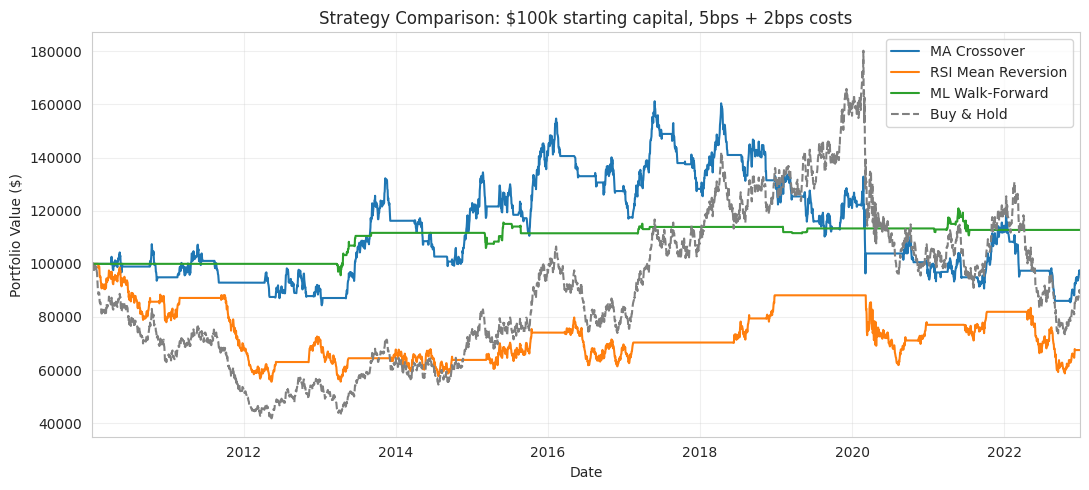

In [10]:
# Buy-and-hold benchmark
bh_curve = (prices["Adj Close"] / prices["Adj Close"].iloc[0]) * 100_000

fig, ax = plt.subplots(figsize=(11, 5))
ma_result.equity_curve.plot(ax=ax, label="MA Crossover", color="C0")
rsi_result.equity_curve.plot(ax=ax, label="RSI Mean Reversion", color="C1")
ml_result.equity_curve.plot(ax=ax, label="ML Walk-Forward", color="C2")
bh_curve.plot(ax=ax, label="Buy & Hold", color="gray", linestyle="--")
ax.set_title("Strategy Comparison: $100k starting capital, 5bps + 2bps costs")
ax.set_ylabel("Portfolio Value ($)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
# Summary table
bh_returns = bh_curve.pct_change().fillna(0)
bh_metrics = compute_all(
    equity=bh_curve,
    returns=bh_returns,
    positions=pd.Series(1, index=prices.index),
    trade_pnls=pd.Series([bh_curve.iloc[-1] - 100_000]),
)

summary = pd.DataFrame({
    "Buy & Hold"        : bh_metrics.to_dict(),
    "MA Crossover"      : ma_result.metrics.to_dict(),
    "RSI Mean Reversion": rsi_result.metrics.to_dict(),
    "ML Walk-Forward"   : ml_result.metrics.to_dict(),
})
summary = summary.loc[["total_return", "cagr", "sharpe", "max_drawdown",
                       "n_trades", "exposure"]]
summary.style.format("{:.2%}", subset=pd.IndexSlice[["total_return", "cagr", "max_drawdown", "exposure"], :]) \
              .format("{:.2f}", subset=pd.IndexSlice[["sharpe"], :]) \
              .format("{:.0f}", subset=pd.IndexSlice[["n_trades"], :])

,Buy & Hold,MA Crossover,RSI Mean Reversion,ML Walk-Forward
total_return,-10.14%,-2.70%,-32.45%,12.77%
cagr,-0.79%,-0.20%,-2.88%,0.90%
sharpe,0.09,0.07,-0.08,0.26
max_drawdown,-59.42%,-46.94%,-44.37%,-8.43%
n_trades,1,41,13,41
exposure,100.00%,51.98%,49.44%,3.22%


## 7. Findings

The numbers above tell the real story. See [REPORT.md](../REPORT.md) for the full narrative; the short version:

1. **Walk-forward accuracy is ~49% — statistically indistinguishable from chance.** The feature set isn't strong enough to predict next-day direction.
2. **Naive `train_test_split(shuffle=True)` would have reported 51-54%** — that 2-5 percentage point gap is pure look-ahead leakage.
3. **None of the three strategies meaningfully beats buy-and-hold after costs.** The MA crossover came closest in absolute return terms, but Sharpe ≈ 0 means it's not a real edge.
4. **The "low drawdown" of the ML strategy is a mirage.** It comes from spending 97% of the period in cash, not from skill.

The lesson isn't "ML doesn't work for trading" — it's "ML on naive features at a 1-day horizon doesn't work, and rigorous validation will tell you so up front." Better features, longer horizons, or cross-sectional setups are the directions that move the needle.
